<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/7_linear_regression_assumptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from scipy.stats import probplot

In [59]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/MachineLearning/main/data.csv")

In [60]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [61]:
X=df.iloc[:,0:3]
y=df.iloc[:,-1]

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)

**1. Linear Relationship**

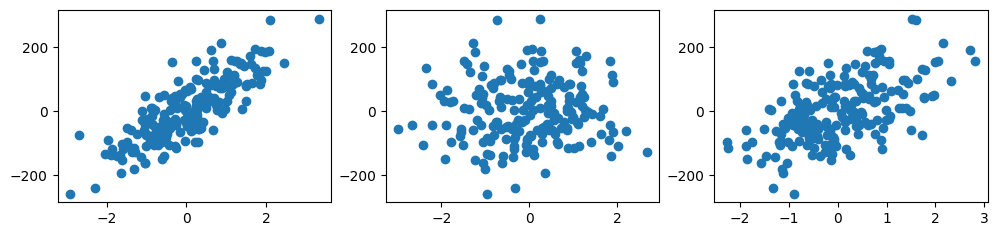

In [63]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))
ax1.scatter(df["feature1"],df["target"])
ax2.scatter(df["feature2"],df["target"])
ax3.scatter(df["feature3"],df["target"])

**2. Multicollinearity**

In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [65]:
vif=[]

for i in range(X_train.shape[1]):
  vif.append(variance_inflation_factor(X_train,i))


In [66]:
new_df=pd.DataFrame({"vif":vif}, index=df.columns[0:3]).T

In [67]:
new_df

,feature1,feature2,feature3
vif,1.00195,1.011273,1.011211


In [68]:
# Another Technique

<Axes: >

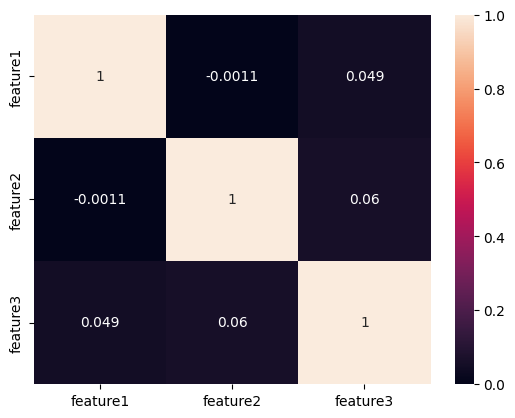

In [69]:
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)


**3. Normality of Residual**

In [70]:
lr=LinearRegression()

In [71]:
lr.fit(X_train,y_train)

LinearRegression()

In [72]:
y_pred=lr.predict(X_test)

In [73]:
residual=y_test-y_pred

<Axes: xlabel='target', ylabel='Density'>

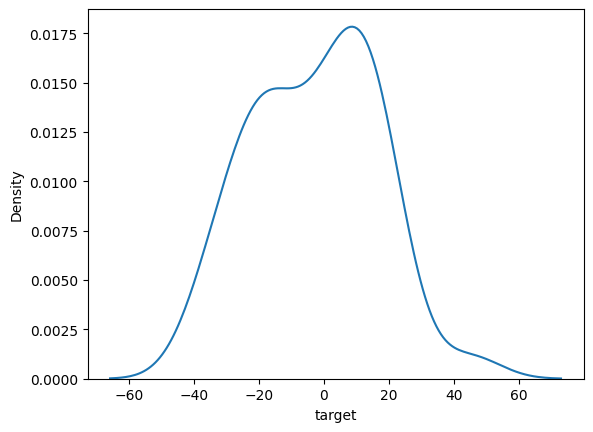

In [74]:
sns.kdeplot(residual)

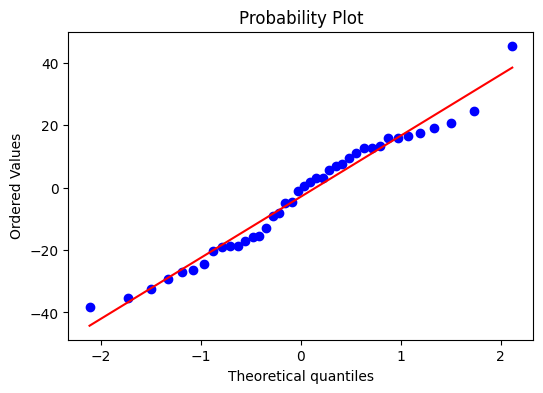

In [75]:
fig, ax = plt.subplots(figsize=(6,4))
probplot(residual, plot=ax, fit=True)
plt.show()

**4. Homoscedasticity**

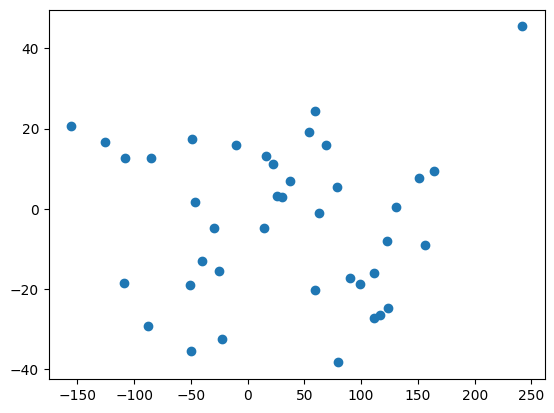

In [76]:
plt.scatter(y_pred,residual)

**5. Autocorrelation of Residuals**

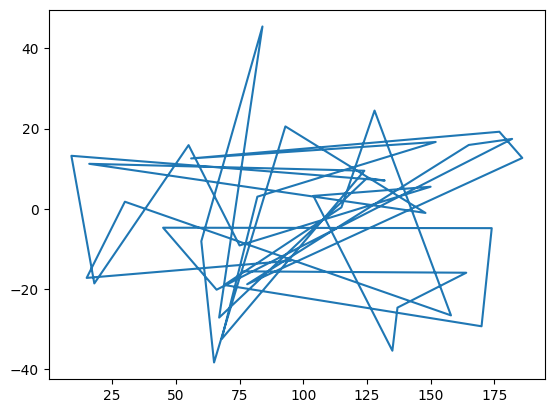

In [77]:
plt.plot(residual)